# -----------------------------------------
# Imports
# -----------------------------------------

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA #kahesh tedad vigegi ha 
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import random
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.cluster import MiniBatchKMeans
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------
# 1)Load data
# -----------------------------------------

In [25]:
df = pd.read_csv("USA Real Estate.csv")

print("Dataset shape:", df.shape) 
print("\nMissing values in each column:\n")
print(df.isnull().sum())

Dataset shape: (2226382, 12)

Missing values in each column:

brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64


# -----------------------------------------
# 2) Handle Missing Values
# -----------------------------------------

In [26]:
# Numerical columns
numerical_cols = ['price', 'bed', 'bath', 'acre_lot', 'house_size']

# Fill missing values using median
for col in numerical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Drop column with mostly missing values
if 'prev_sold_date' in df.columns:
    df.drop(columns=['prev_sold_date'], inplace=True)

print("\nMissing values after handling:\n")
print(df.isnull().sum())


Missing values after handling:

brokered_by     4533
status             0
price              0
bed                0
bath               0
acre_lot           0
street         10866
city            1407
state              8
zip_code         299
house_size         0
dtype: int64


# -----------------------------------------
# 3) Min-Max Normalization
# -----------------------------------------

In [27]:
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[numerical_cols])

scaled_df = pd.DataFrame(
    scaled_features,
    columns=numerical_cols
)

print("\nMin-Max scaled data preview:\n")
print(scaled_df.head())


Min-Max scaled data preview:

      price       bed      bath      acre_lot    house_size
0  0.000049  0.004237  0.001206  1.200000e-06  8.804303e-07
1  0.000037  0.006356  0.001206  8.000000e-07  1.463859e-06
2  0.000031  0.002119  0.000000  1.500000e-06  7.151093e-07
3  0.000068  0.006356  0.001206  1.000000e-06  1.726258e-06
4  0.000030  0.010593  0.001206  5.000000e-07  1.687812e-06


# -----------------------------------------
# 4) Whitening using PCA
# -----------------------------------------

In [28]:
pca = PCA(whiten=True)
whitened_features = pca.fit_transform(scaled_df)

whitened_df = pd.DataFrame(
    whitened_features,
    columns=[f'PC{i+1}' for i in range(whitened_features.shape[1])]
)

print("\nWhitened features preview:\n")
print(whitened_df.head())


Whitened features preview:

        PC1       PC2       PC3       PC4       PC5
0 -0.018385 -0.193418 -0.194592 -0.128783 -0.001984
1 -0.018352  0.417423 -0.831559 -0.083374 -0.001435
2 -0.018395 -0.957802 -0.366601  0.007094 -0.001575
3 -0.018315  0.417855 -0.827823 -0.052762 -0.001050
4 -0.018211  1.639338 -2.103483  0.023927 -0.001746


# -----------------------------------------
# 5) Correlation Heatmap
# -----------------------------------------

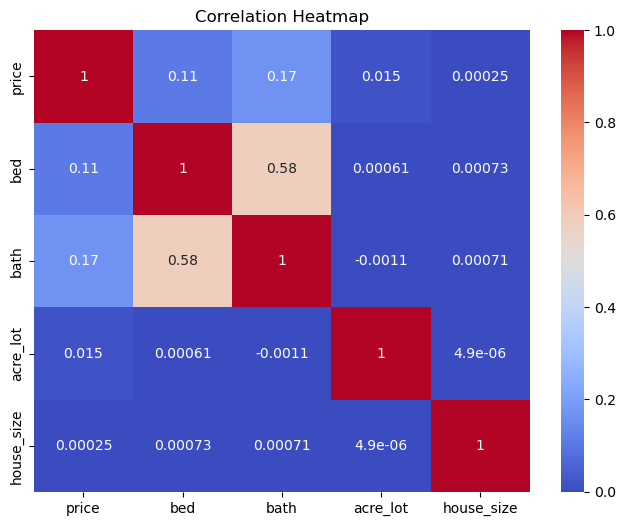

In [29]:
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------------------
# 6) Select Top 3 Features Based on Correlation
# -----------------------------------------

In [30]:
correlation_with_price = corr_matrix['price'].abs().sort_values(ascending=False)

# Exclude target itself
top_3_features = correlation_with_price.index[1:4].tolist()

print("\nTop 3 selected features based on correlation with price:")
print(top_3_features)



Top 3 selected features based on correlation with price:
['bath', 'bed', 'acre_lot']


# =========================================
# Section 2: Clustering & Classification
# =========================================

# -----------------------------------------
# 1) K-Means Clustering - Elbow Method
# -----------------------------------------

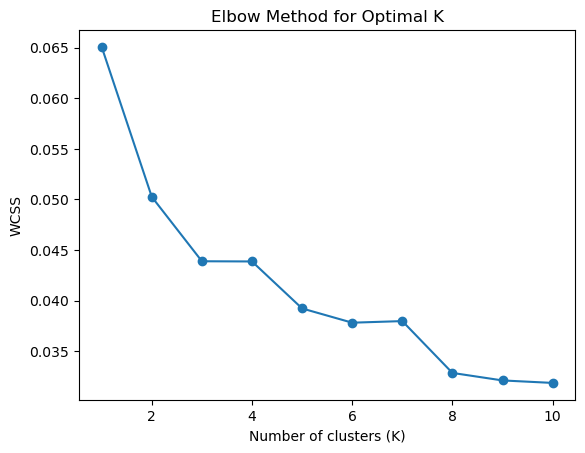

In [32]:
X_cluster = scaled_df.copy()

if len(X_cluster) > 5000:
    X_used = X_cluster.sample(n=5000, random_state=42)
else:
    X_used = X_cluster

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        n_init=3,
        batch_size=1024
    )
    kmeans.fit(X_used)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()


# -----------------------------------------
# 2) Train K-Means with Optimal K
# -----------------------------------------

In [33]:
optimal_k = 3  # selected based on elbow curve

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster)

# Add cluster labels as categorical target
df['cluster_label'] = cluster_labels

# -----------------------------------------
# 3) Prepare Data for Supervised Learning
# -----------------------------------------

In [34]:
X = X_cluster
y = df['cluster_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------------
# 4) K-Nearest Neighbors (KNN)
# -----------------------------------------

In [35]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 1.0


# -----------------------------------------
# 5) Decision Tree Classifier
# -----------------------------------------

In [36]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


# -----------------------------------------
# 6) Model Comparison
# -----------------------------------------

In [37]:
print("\nModel Comparison")
print("KNN Accuracy:", knn_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)



Model Comparison
KNN Accuracy: 1.0
Decision Tree Accuracy: 1.0


# -----------------------------------------
# 7) Visualize Decision Tree
# -----------------------------------------

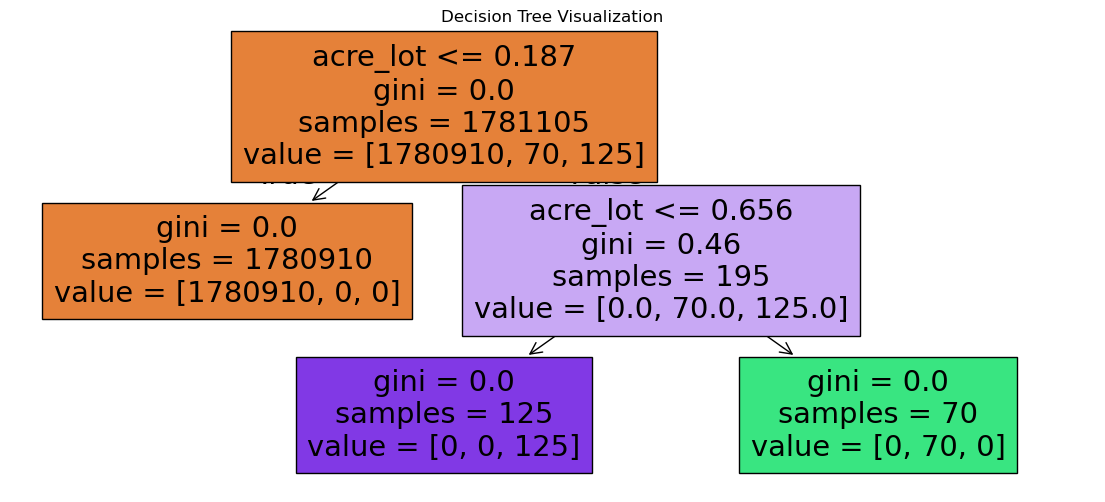

In [38]:
plt.figure(figsize=(14, 6))
plot_tree(
    dt,
    feature_names=X.columns,
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()


# =========================================
# Section 3: Feature Selection using GA
# =========================================

# -----------------------------------------
# 1) Prepare Data
# -----------------------------------------

In [39]:
X = scaled_df.copy()
y = df['price']

n_features = X.shape[1]

# -----------------------------------------
# 2) Fitness Function
# -----------------------------------------

In [40]:
def fitness_function(chromosome):
    # if no feature selected
    if sum(chromosome) == 0:
        return 0

    selected_features = [
        feature for bit, feature in zip(chromosome, X.columns) if bit == 1
    ]

    X_selected = X[selected_features]

    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y, test_size=0.2, random_state=42
    )

    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)

    return score


# -----------------------------------------
# 3) Initialize Population
# -----------------------------------------

In [41]:

population_size = 20
generations = 30
mutation_rate = 0.1

population = [
    [random.randint(0, 1) for _ in range(n_features)]
    for _ in range(population_size)
]


# -----------------------------------------
# 4) Genetic Algorithm Loop
# -----------------------------------------

In [42]:
for gen in range(generations):
    fitness_scores = [fitness_function(ind) for ind in population]

    # Selection (Top 50%)
    sorted_population = [
        ind for _, ind in sorted(
            zip(fitness_scores, population),
            key=lambda x: x[0],
            reverse=True
        )
    ]
    population = sorted_population[:population_size // 2]

    # Crossover
    children = []
    while len(children) < population_size // 2:
        parent1, parent2 = random.sample(population, 2)
        crossover_point = random.randint(1, n_features - 1)

        child = (
            parent1[:crossover_point] +
            parent2[crossover_point:]
        )
        children.append(child)

    population += children

    # Mutation
    for individual in population:
        if random.random() < mutation_rate:
            mutation_point = random.randint(0, n_features - 1)
            individual[mutation_point] = 1 - individual[mutation_point]


# -----------------------------------------
# 5) Best Feature Set
# -----------------------------------------

In [43]:
fitness_scores = [fitness_function(ind) for ind in population]
best_individual = population[np.argmax(fitness_scores)]

selected_features_ga = [
    feature for bit, feature in zip(best_individual, X.columns) if bit == 1
]

print("Selected features by GA:")
print(selected_features_ga)


Selected features by GA:
['price', 'bath', 'acre_lot', 'house_size']
